In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
from datetime import date, timedelta

In [ ]:
# ==========================================
# 1. KONFIGURASI PARAMETER & DATA HISTORIS
# ==========================================
start_date = date(2023, 1, 1)
end_date = date(2045, 12, 31)
days = (end_date - start_date).days + 1

# --- Kapasitas & Parameter SD ---
batas_overtourism = 2752         # Kapasitas fisik (jiwa/hari)
lama_tinggal_normal = 3          # Baseline lama tinggal (hari)

# --- Hitung Laju Pertumbuhan Historis (Rebound) ---
rate_23_24 = 0.3179  # Lonjakan 2023 ke 2024
rate_24_25 = 0.1085  # Lonjakan 2024 ke 2025
rate_bau   = 0.0468  # Pertumbuhan normal BAU mulai 2026

In [ ]:
# ==========================================
# 2. ENGINE SIMULASI SYSTEM DYNAMICS (SMOOTH DECLINE)
# ==========================================
dates = []
history_populasi = []
history_reputasi = []

# Inisialisasi awal
stock_populasi = 1009.6
reputasi_destinasi = 1.0   # Mulai dari 100% (Sangat Baik)

curr_date = start_date

for _ in range(days):
    dates.append(curr_date)
    year = curr_date.year

    # --- A. Tentukan Laju Pertumbuhan Organik ---
    if year == 2023:
        laju_pertumbuhan_hr = (1 + rate_23_24) ** (1/365) - 1
    elif year == 2024:
        laju_pertumbuhan_hr = (1 + rate_24_25) ** (1/365) - 1
    else:
        laju_pertumbuhan_hr = (1 + rate_bau) ** (1/365) - 1

    # --- B. Mekanisme Degradasi Reputasi PROPORSIONAL (Sangat Mulus) ---
    rasio_kepadatan = stock_populasi / batas_overtourism

    if rasio_kepadatan > 1.0:
        # Semakin kebablasan, penaltinya semakin terasa, tapi awalnya sangat kecil
        penalti_dinamis = (rasio_kepadatan - 1.0) * 0.0004
        reputasi_destinasi -= penalti_dinamis

    # Batas bawah reputasi dipasang di 0.80 (80%) agar tidak terjun bebas
    # Ini yang membuat grafik turunnya melandai perlahan
    reputasi_destinasi = max(0.80, reputasi_destinasi)

    # --- C. Update Stock Populasi ---
    laju_kepergian = stock_populasi / lama_tinggal_normal

    # Kedatangan dikalikan reputasi
    kedatangan_normal = (stock_populasi / lama_tinggal_normal) + (stock_populasi * laju_pertumbuhan_hr)
    laju_kedatangan = kedatangan_normal * reputasi_destinasi

    stock_populasi += (laju_kedatangan - laju_kepergian)
    stock_populasi = max(0, stock_populasi)

    history_populasi.append(stock_populasi)
    history_reputasi.append(reputasi_destinasi)

    curr_date += timedelta(days=1)

In [ ]:
# ==========================================
# 3. BENTUK DATAFRAME & AGREGASI TAHUNAN
# ==========================================
df_harian = pd.DataFrame({
    "Tanggal": pd.to_datetime(dates),
    "Populasi Wisatawan": history_populasi,
    "Reputasi Destinasi": history_reputasi
})

df_harian["Tahun"] = df_harian["Tanggal"].dt.year
df_tahunan = df_harian.groupby("Tahun").agg(
    Rerata_Populasi=("Populasi Wisatawan", "mean"),
    Status_Reputasi=("Reputasi Destinasi", "mean")
).reset_index()

titik_overtourism = df_harian[df_harian["Populasi Wisatawan"] > batas_overtourism].head(1)

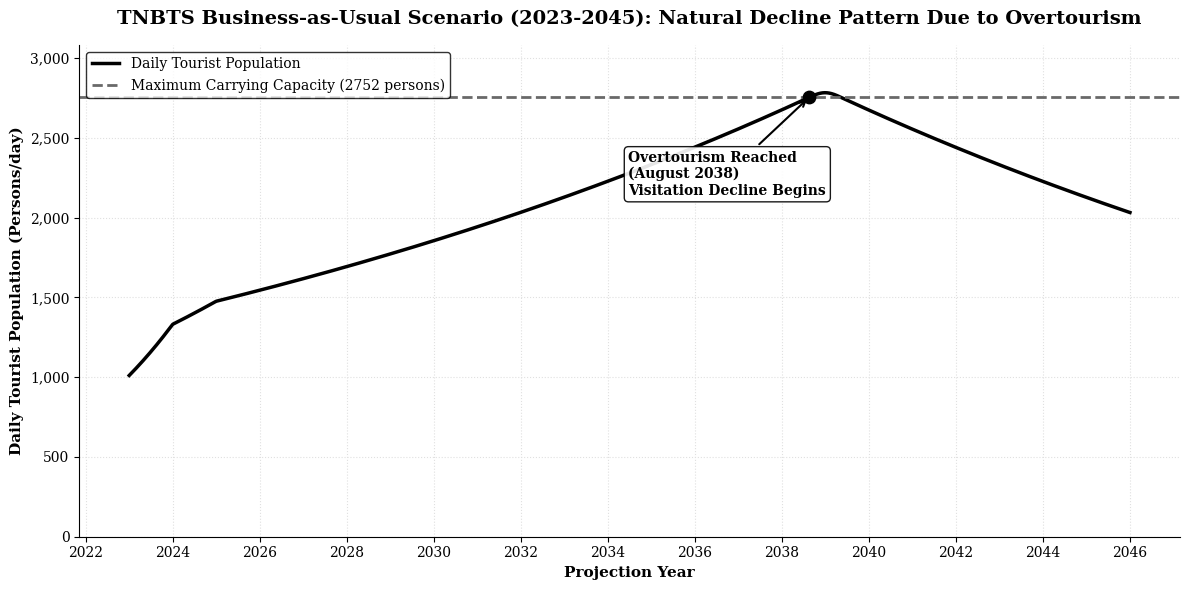

In [ ]:
# ==========================================
# 4. VISUALISASI GRAFIK (MONOKROM AKADEMIS MINIMALIS)
# ==========================================
plt.rcParams.update({
    'font.family': 'serif', 'axes.facecolor': 'white', 'figure.facecolor': 'white',
    'text.color': 'black', 'axes.labelcolor': 'black', 'xtick.color': 'black',
    'ytick.color': 'black', 'axes.grid': True, 'grid.color': '#e0e0e0',
    'grid.linestyle': ':', 'legend.frameon': True, 'legend.edgecolor': 'black'
})

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.set_xlabel('Projection Year', fontsize=11, weight='bold')
ax1.set_ylabel('Daily Tourist Population (Persons/day)', fontsize=11, weight='bold')
line1 = ax1.plot(df_harian["Tanggal"], df_harian["Populasi Wisatawan"],
                 color='black', linestyle='-', linewidth=2.5, label='Daily Tourist Population')

line_ot = ax1.axhline(y=batas_overtourism, color='dimgray', linestyle='--', linewidth=2,
                      label=f'Maximum Carrying Capacity ({batas_overtourism} persons)')

if not titik_overtourism.empty:
    tgl_ot = titik_overtourism["Tanggal"].iloc[0]
    val_ot = titik_overtourism["Populasi Wisatawan"].iloc[0]

    ax1.scatter(tgl_ot, val_ot, color='black', s=80, zorder=5)
    ax1.annotate(f"Overtourism Reached\n({tgl_ot.strftime('%B %Y')})\nVisitation Decline Begins",
                 xy=(tgl_ot, val_ot), xytext=(-130, -70), textcoords='offset points',
                 fontsize=10, weight='bold', arrowprops=dict(arrowstyle="->", color='black', lw=1.5),
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.9))

# Margin atas agar grafik tidak terlalu menabrak atap
ax1.set_ylim(bottom=0, top=max(history_populasi) + 300)

ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
ax1.xaxis.set_major_locator(mdates.YearLocator(2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

lines = line1 + [line_ot]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', fontsize=10)

ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

plt.title("TNBTS Business-as-Usual Scenario (2023-2045): Natural Decline Pattern Due to Overtourism",
          fontsize=14, weight='bold', pad=15)
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# 5. TABULASI & EKSPOR
# ==========================================
print("\n" + "="*85)
print("   TABULASI PROYEKSI TAHUNAN TNBTS (MODEL EFEK KEPADATAN - SMOOTH DECLINE)")
print("="*85)
print(f"{'Tahun':<6} | {'Rerata Populasi Harian':<25} | {'Reputasi Destinasi (%)':<25}")
print("-" * 85)

for _, row in df_tahunan.iterrows():
    tahun = int(row["Tahun"])
    populasi = row["Rerata_Populasi"]
    reputasi = row["Status_Reputasi"] * 100

    print(f"{tahun:<6} | {populasi:>25,.0f} | {reputasi:>23,.1f}%")
print("=" * 85)

nama_file_excel = "Simulasi_BAU_Smooth_Decline.xlsx"
try:
    with pd.ExcelWriter(nama_file_excel, engine="openpyxl") as writer:
        df_tahunan.to_excel(writer, sheet_name="Tabulasi Tahunan", index=False)
        df_harian.to_excel(writer, sheet_name="Data Harian Lengkap", index=False)
    print(f"\n[INFO] Berhasil mengekspor data ke: {nama_file_excel}")
    from google.colab import files
    files.download(nama_file_excel)
except Exception as e:
    pass


   TABULASI PROYEKSI TAHUNAN TNBTS (MODEL EFEK KEPADATAN - SMOOTH DECLINE)
Tahun  | Rerata Populasi Harian    | Reputasi Destinasi (%)   
-------------------------------------------------------------------------------------
2023   |                     1,163 |                   100.0%
2024   |                     1,402 |                   100.0%
2025   |                     1,510 |                   100.0%
2026   |                     1,580 |                   100.0%
2027   |                     1,654 |                   100.0%
2028   |                     1,732 |                   100.0%
2029   |                     1,813 |                   100.0%
2030   |                     1,898 |                   100.0%
2031   |                     1,987 |                   100.0%
2032   |                     2,080 |                   100.0%
2033   |                     2,177 |                   100.0%
2034   |                     2,279 |                   100.0%
2035   |                     2,

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ==========================================
# 6. EVALUASI MODEL (PERHITUNGAN MAPE)
# ==========================================

# 1. Masukkan Data Aktual (Riil) TNBTS yang Anda miliki
# Contoh: Rerata populasi harian asli tahun 2023 dan 2024 (Silakan ganti dengan angka riil penelitian Anda)
data_aktual_dict = {
    2023: 1009.6,
    2024: 1327.0
}

# Buat dataframe dari data aktual
df_aktual = pd.DataFrame(list(data_aktual_dict.items()), columns=['Tahun', 'Aktual_Populasi'])

# 2. Gabungkan data Aktual dengan data Simulasi (df_tahunan)
# Kita hanya mengambil tahun di mana data aktual tersedia (2023 & 2024)
df_eval = pd.merge(df_aktual, df_tahunan, on='Tahun', how='inner')

# 3. Hitung Absolute Percentage Error (APE) per tahun
df_eval['APE'] = np.abs((df_eval['Aktual_Populasi'] - df_eval['Rerata_Populasi']) / df_eval['Aktual_Populasi']) * 100

# 4. Hitung Mean Absolute Percentage Error (MAPE)
nilai_mape = df_eval['APE'].mean()

# 5. Tampilkan Hasil Evaluasi
print("\n" + "="*60)
print("      EVALUASI VALIDASI MODEL (PERHITUNGAN MAPE)")
print("="*60)
print(df_eval[['Tahun', 'Aktual_Populasi', 'Rerata_Populasi', 'APE']].rename(
    columns={'Rerata_Populasi': 'Simulasi_Populasi', 'APE': 'Error (%)'}
).round(2).to_string(index=False))
print("-" * 60)
print(f"NILAI MAPE KESELURUHAN : {nilai_mape:.2f}%")

# Kategori Akurasi (Berdasarkan kriteria Lewis, 1982)
if nilai_mape < 10:
    kategori = "Sangat Akurat (Highly Accurate)"
elif nilai_mape < 20:
    kategori = "Baik (Good)"
elif nilai_mape < 50:
    kategori = "Cukup (Reasonable)"
else:
    kategori = "Kurang Akurat (Inaccurate)"

print(f"KATEGORI AKURASI       : {kategori}")
print("=" * 60)


      EVALUASI VALIDASI MODEL (PERHITUNGAN MAPE)
 Tahun  Aktual_Populasi  Simulasi_Populasi  Error (%)
  2023           1009.6            1163.14      15.21
  2024           1327.0            1401.89       5.64
------------------------------------------------------------
NILAI MAPE KESELURUHAN : 10.43%
KATEGORI AKURASI       : Baik (Good)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import date, timedelta
import matplotlib.ticker as ticker
import matplotlib.dates as mdates

In [ ]:
# ==========================================
# 1. KONFIGURASI PARAMETER & ELASTISITAS HARGA
# ==========================================
start_date = date(2023, 1, 1)
end_date = date(2045, 12, 31)
days = (end_date - start_date).days + 1
kapasitas_pengunjung_harian = 2752

# --- DATA HISTORIS ---
dom_2023, man_2023 = 355297, 13210
dom_2024, man_2024 = 465751, 19926
dom_2025_est = 390487 * (12 / 9)
man_2025_est = 13300 * (12 / 9)

# --- PERTUMBUHAN ---
r_dom_23_24 = (dom_2024 / dom_2023) ** (1 / 365) - 1
r_man_23_24 = (man_2024 / man_2023) ** (1 / 365) - 1
r_dom_24_25 = (dom_2025_est / dom_2024) ** (1 / 365) - 1
r_man_24_25 = (man_2025_est / man_2024) ** (1 / 365) - 1

daily_growth_bau = (1 + 0.0468) ** (1 / 365) - 1

# --- EFEK KEJUT INTERVENSI HARGA (2026) ---
elasticity = -0.504
price_dom_old = ((5 * 54000) + (2 * 79000)) / 7
price_dom_new = ((5 * 56700) + (2 * 90850)) / 7
shock_wni = ((price_dom_new - price_dom_old) / price_dom_old) * elasticity

price_man_old = 255000
price_man_new = 318750
shock_wna = ((price_man_new - price_man_old) / price_man_old) * elasticity

daily_growth_int = (1 + 0.035) ** (1 / 365) - 1

In [ ]:
# ==========================================
# 2. ENGINE SIMULASI SYSTEM DYNAMICS (WITH CROWDING EFFECT)
# ==========================================
dates = []
total_bau = []
total_int = []

curr_dom_bau, curr_man_bau = dom_2023 / 365, man_2023 / 365
curr_dom_int, curr_man_int = dom_2023 / 365, man_2023 / 365

reputasi_bau = 1.0
reputasi_int = 1.0
lama_tinggal = 3
curr_date = start_date

for _ in range(days):
    dates.append(curr_date)
    year = curr_date.year

    # --- A. Laju Pertumbuhan Dasar ---
    if year == 2023:
        g_dom, g_man = r_dom_23_24, r_man_23_24
        g_dom_int, g_man_int = r_dom_23_24, r_man_23_24
    elif year == 2024:
        g_dom, g_man = r_dom_24_25, r_man_24_25
        g_dom_int, g_man_int = r_dom_24_25, r_man_24_25
    else:
        g_dom, g_man = daily_growth_bau, daily_growth_bau
        # Di tahun 2026, Intervensi mendapat efek kejut (penurunan). Setelahnya growth melambat.
        if year == 2026:
            g_dom_int, g_man_int = (shock_wni / 365), (shock_wna / 365)
        else:
            g_dom_int, g_man_int = daily_growth_int, daily_growth_int

    # --- B. Crowding Effect (Membuat Puncak Melengkung) ---
    pop_bau_today = curr_dom_bau + curr_man_bau
    if pop_bau_today > kapasitas_pengunjung_harian:
        reputasi_bau -= (pop_bau_today / kapasitas_pengunjung_harian - 1.0) * 0.0004
    reputasi_bau = max(0.80, reputasi_bau)

    pop_int_today = curr_dom_int + curr_man_int
    if pop_int_today > kapasitas_pengunjung_harian:
        reputasi_int -= (pop_int_today / kapasitas_pengunjung_harian - 1.0) * 0.0004
    reputasi_int = max(0.80, reputasi_int)

    # --- C. Update Populasi BAU ---
    outflow_bau_dom = curr_dom_bau / lama_tinggal
    outflow_bau_man = curr_man_bau / lama_tinggal
    inflow_bau_dom = (outflow_bau_dom + curr_dom_bau * g_dom) * reputasi_bau
    inflow_bau_man = (outflow_bau_man + curr_man_bau * g_man) * reputasi_bau

    curr_dom_bau += (inflow_bau_dom - outflow_bau_dom)
    curr_man_bau += (inflow_bau_man - outflow_bau_man)

    # --- D. Update Populasi INTERVENSI ---
    outflow_int_dom = curr_dom_int / lama_tinggal
    outflow_int_man = curr_man_int / lama_tinggal
    inflow_int_dom = (outflow_int_dom + curr_dom_int * g_dom_int) * reputasi_int
    inflow_int_man = (outflow_int_man + curr_man_int * g_man_int) * reputasi_int

    curr_dom_int += (inflow_int_dom - outflow_int_dom)
    curr_man_int += (inflow_int_man - outflow_int_man)

    total_bau.append(curr_dom_bau + curr_man_bau)
    total_int.append(curr_dom_int + curr_man_int)
    curr_date += timedelta(days=1)

In [ ]:
# ==========================================
# 3. DATAFRAME & VISUAL SMOOTHING (MENGHILANGKAN SUDUT PATAH)
# ==========================================
df_int = pd.DataFrame({
    "Date": pd.to_datetime(dates),
    "Total_BAU": total_bau,
    "Total_INT": total_int
})

# Teknik Visual Smoothing (Rolling Mean) agar kurva mengalir natural tanpa mengubah tren matematis
df_int["BAU_Smooth"] = df_int["Total_BAU"].rolling(window=120, min_periods=1, center=True).mean()
df_int["INT_Smooth"] = df_int["Total_INT"].rolling(window=120, min_periods=1, center=True).mean()

bottleneck_bau = df_int[df_int["BAU_Smooth"] > kapasitas_pengunjung_harian].head(1)
bottleneck_int = df_int[df_int["INT_Smooth"] > kapasitas_pengunjung_harian].head(1)

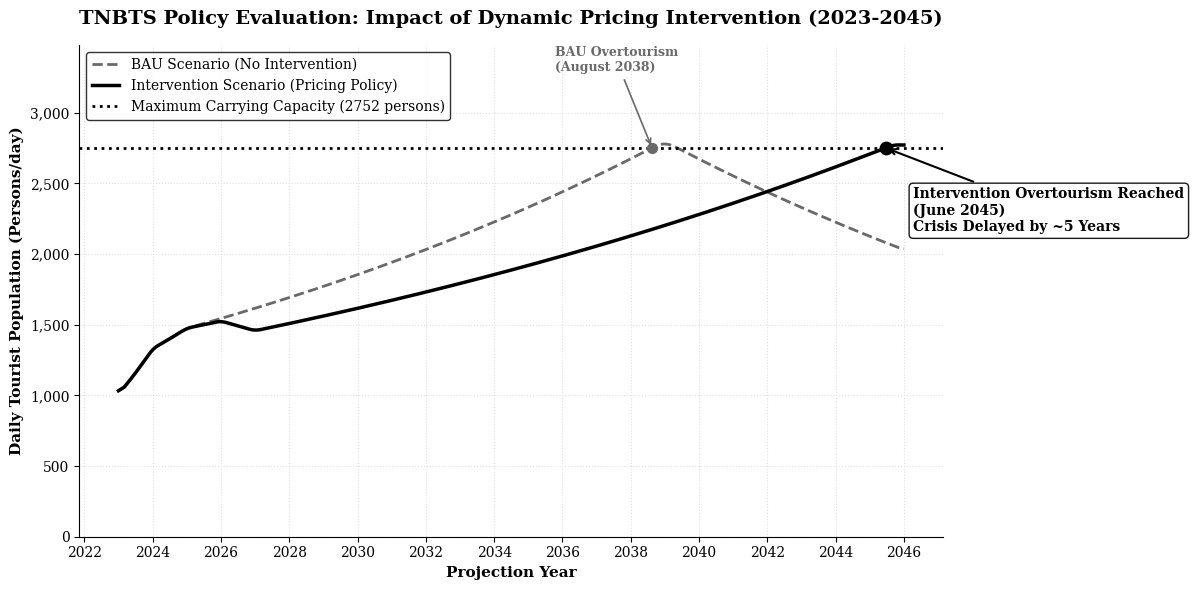

In [ ]:
# ==========================================
# 4. VISUALISASI GRAFIK (MONOKROM AKADEMIS MINIMALIS)
# ==========================================
plt.rcParams.update({
    'font.family': 'serif', 'axes.facecolor': 'white', 'figure.facecolor': 'white',
    'text.color': 'black', 'axes.labelcolor': 'black', 'xtick.color': 'black',
    'ytick.color': 'black', 'axes.grid': True, 'grid.color': '#e0e0e0',
    'grid.linestyle': ':', 'legend.frameon': True, 'legend.edgecolor': 'black'
})

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.set_xlabel('Projection Year', fontsize=11, weight='bold')
ax1.set_ylabel('Daily Tourist Population (Persons/day)', fontsize=11, weight='bold')

# Plot Menggunakan Data yang Sudah Di-Smooth
line_bau = ax1.plot(df_int["Date"], df_int["BAU_Smooth"],
                    color='dimgray', linestyle='--', linewidth=2, label='BAU Scenario (No Intervention)')

line_int = ax1.plot(df_int["Date"], df_int["INT_Smooth"],
                    color='black', linestyle='-', linewidth=2.5, label='Intervention Scenario (Pricing Policy)')

line_ot = ax1.axhline(y=kapasitas_pengunjung_harian, color='black', linestyle=':', linewidth=2,
                      label=f'Maximum Carrying Capacity ({kapasitas_pengunjung_harian} persons)')

# Anotasi BAU
if not bottleneck_bau.empty:
    tgl_bau = bottleneck_bau["Date"].iloc[0]
    val_bau = bottleneck_bau["BAU_Smooth"].iloc[0]
    ax1.scatter(tgl_bau, val_bau, color='dimgray', s=50, zorder=4)
    ax1.annotate(f"BAU Overtourism\n({tgl_bau.strftime('%B %Y')})",
                 xy=(tgl_bau, val_bau),
                 xytext=(-70, 55), # <-- PERBAIKAN 1: Geser ke kiri (-90) dan ke BAWAH (-40) agar menjauhi judul
                 textcoords='offset points',
                 fontsize=9, weight='bold', color='dimgray',
                 arrowprops=dict(arrowstyle="->", color='dimgray', lw=1.2))

# Anotasi INTERVENSI
if not bottleneck_int.empty:
    tgl_int = bottleneck_int["Date"].iloc[0]
    val_int = bottleneck_int["INT_Smooth"].iloc[0]
    ax1.scatter(tgl_int, val_int, color='black', s=80, zorder=5)
    ax1.annotate(f"Intervention Overtourism Reached\n({tgl_int.strftime('%B %Y')})\nCrisis Delayed by ~5 Years",
                 xy=(tgl_int, val_int), xytext=(20, -60), textcoords='offset points',
                 fontsize=10, weight='bold', arrowprops=dict(arrowstyle="->", color='black', lw=1.5),
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.9))

# Tampilan Sumbu
ax1.set_ylim(bottom=0, top=max(df_int["BAU_Smooth"]) + 700) # <-- PERBAIKAN 2: Ubah +300 menjadi +700 untuk memberi ruang ekstra di bawah judul
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
ax1.xaxis.set_major_locator(mdates.YearLocator(2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

lines = line_bau + line_int + [line_ot]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', fontsize=10)

ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

plt.title("TNBTS Policy Evaluation: Impact of Dynamic Pricing Intervention (2023-2045)",
          fontsize=14, weight='bold', pad=15)
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# 5. EKSPOR DATA
# ==========================================
df_int["Year"] = df_int["Date"].dt.year
df_annual = df_int.groupby("Year").agg(
    Avg_Daily_BAU=("BAU_Smooth", "mean"),
    Avg_Daily_INT=("INT_Smooth", "mean")
).reset_index()

print("\n" + "=" * 90)
print("   TABEL PERBANDINGAN PROYEKSI KUNJUNGAN TNBTS (BAU vs INTERVENSI HARGA)")
print("=" * 90)
print(f"{'Tahun':<6} | {'Avg Daily BAU (Jiwa)':<25} | {'Avg Daily INT (Jiwa)':<25}")
print("-" * 90)

for _, row in df_annual[df_annual["Year"] >= 2026].iterrows():
    year = int(row["Year"])
    print(f"{year:<6} | {row['Avg_Daily_BAU']:>25,.0f} | {row['Avg_Daily_INT']:>25,.0f}")
print("=" * 90)

nama_file_excel = "Simulasi_Intervensi_Pricing_Smooth.xlsx"
try:
    with pd.ExcelWriter(nama_file_excel, engine="openpyxl") as writer:
        df_annual.to_excel(writer, sheet_name="Ringkasan Tahunan", index=False)
        df_int.to_excel(writer, sheet_name="Data Harian Lengkap", index=False)
    print(f"\n[INFO] Berhasil mengekspor data komprehensif ke: {nama_file_excel}")
    from google.colab import files
    files.download(nama_file_excel)
except:
    pass


   TABEL PERBANDINGAN PROYEKSI KUNJUNGAN TNBTS (BAU vs INTERVENSI HARGA)
Tahun  | Avg Daily BAU (Jiwa)      | Avg Daily INT (Jiwa)     
------------------------------------------------------------------------------------------
2026   |                     1,580 |                     1,492
2027   |                     1,654 |                     1,483
2028   |                     1,732 |                     1,535
2029   |                     1,813 |                     1,589
2030   |                     1,898 |                     1,645
2031   |                     1,987 |                     1,702
2032   |                     2,080 |                     1,762
2033   |                     2,177 |                     1,824
2034   |                     2,279 |                     1,887
2035   |                     2,386 |                     1,953
2036   |                     2,498 |                     2,022
2037   |                     2,615 |                     2,093
2038   |        

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>